In [30]:
%load_ext autoreload
%autoreload 2

from src.dynamical_systems import *
from src.SINDyModel import *
from src.derivatives import *
from src.helpers import *

import matplotlib.pyplot as plt
from tqdm import tqdm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
# make a specific Lotka-Volterra right-hand side function
duffing_oscillator_rhs = generate_duffing_oscillator_rhs(0.2, 0.2, 0.1)

dt = 0.01
t_span = (0, 50)

t_eval = np.arange(t_span[0], t_span[1] + dt, dt)
x0 = (10, 5)

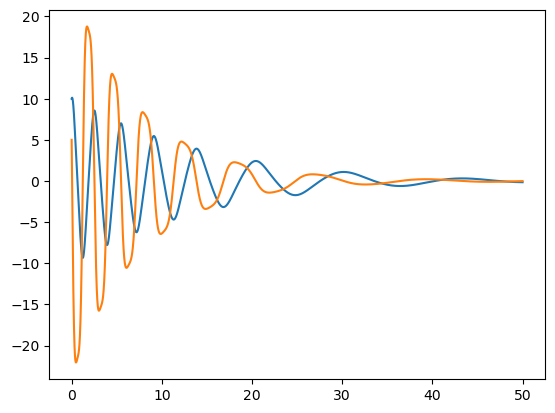

In [32]:
x_train = generate_training_data(duffing_oscillator_rhs, x0, t_eval)

plt.plot(t_eval, x_train.T)
plt.show()

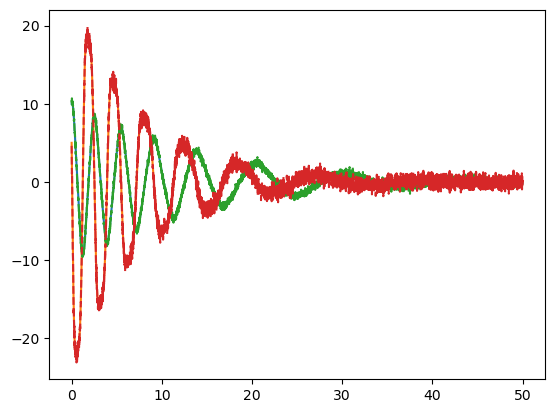

In [33]:
x_train_noisy = add_noise_to_data(x_train, 0.1)

plt.plot(t_eval, x_train.T)
plt.plot(t_eval, x_train_noisy.T, '--')
plt.show()

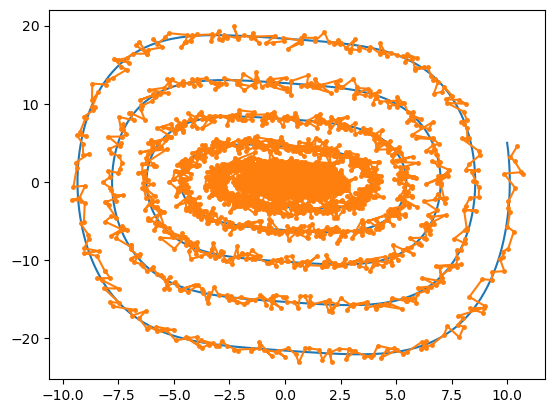

In [34]:
plt.plot(x_train[0], x_train[1])
plt.plot(x_train_noisy[0], x_train_noisy[1], '.-', markersize=5)

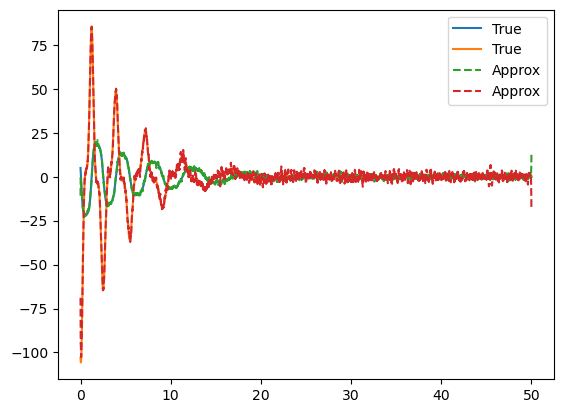

In [45]:
# generate the true derivative
x_dot_true = duffing_oscillator_rhs(t_eval, x_train)

# x_dot_approx = dxdt_finite_difference(x_train_noisy, t_eval)
x_dot_approx = dxdt_poly_fit(x_train_noisy, t_eval, 3, 20)

plt.plot(t_eval, x_dot_true.T, label='True')
plt.plot(t_eval, x_dot_approx.T, '--', label='Approx')
plt.legend()
plt.show()

In [52]:
# generate models for different noise levels

threshold = 0.05

noise_levels = [0, 0.0001, 0.001, 0.01, 0.1, 1]

models = []
for noise_level in tqdm(noise_levels):
    # generate noisy data
    x_train_noisy = add_noise_to_data(x_train, noise_level)
    
    # generate the derivative of the noisy data
    # NOTE: we can change the kind of derivative and the parameters of the derivative method!
    # x_dot_approx = dxdt_finite_difference(x_train_noisy, t_eval)
    x_dot_approx = dxdt_poly_fit(x_train_noisy, t_eval, 3, 20)

    # create and fit a SINDy model
    model = SINDyModel(n_state_vars=2, threshold=threshold, poly_order=5)
    model.fit(x_train_noisy, x_dot_approx)
    models.append(model)


# print the models
for i in range(len(noise_levels)):
    print(f"noise level: {noise_levels[i]}")
    models[i].print(decimals=3)
    print()

100%|██████████| 6/6 [00:06<00:00,  1.07s/it]

noise level: 0
x0' = + 1.000 x1 
x1' = + -0.216 x0 + -0.200 x1 + -0.100 x0^3 

noise level: 0.0001
x0' = + 1.000 x1 
x1' = + -0.216 x0 + -0.200 x1 + -0.100 x0^3 

noise level: 0.001
x0' = + 1.000 x1 
x1' = + -0.216 x0 + -0.200 x1 + -0.100 x0^3 

noise level: 0.01
x0' = + 0.999 x1 
x1' = + -0.223 x0 + -0.200 x1 + -0.099 x0^3 

noise level: 0.1
x0' = + 0.987 x1 
x1' = + -0.198 x1 + -0.101 x0^3 

noise level: 1
x0' = + -0.084 1 + 0.491 x1 
x1' = + -1.897 x0 



In [53]:
# generate predictions for the models

x_preds = []
for model in tqdm(models):
    x_pred = generate_model_prediction(model, x0, t_eval)
    x_preds.append(x_pred)

100%|██████████| 6/6 [00:02<00:00,  2.60it/s]


C:\Users\Elliot\AppData\Local\Temp\ipykernel_15044\2443343160.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


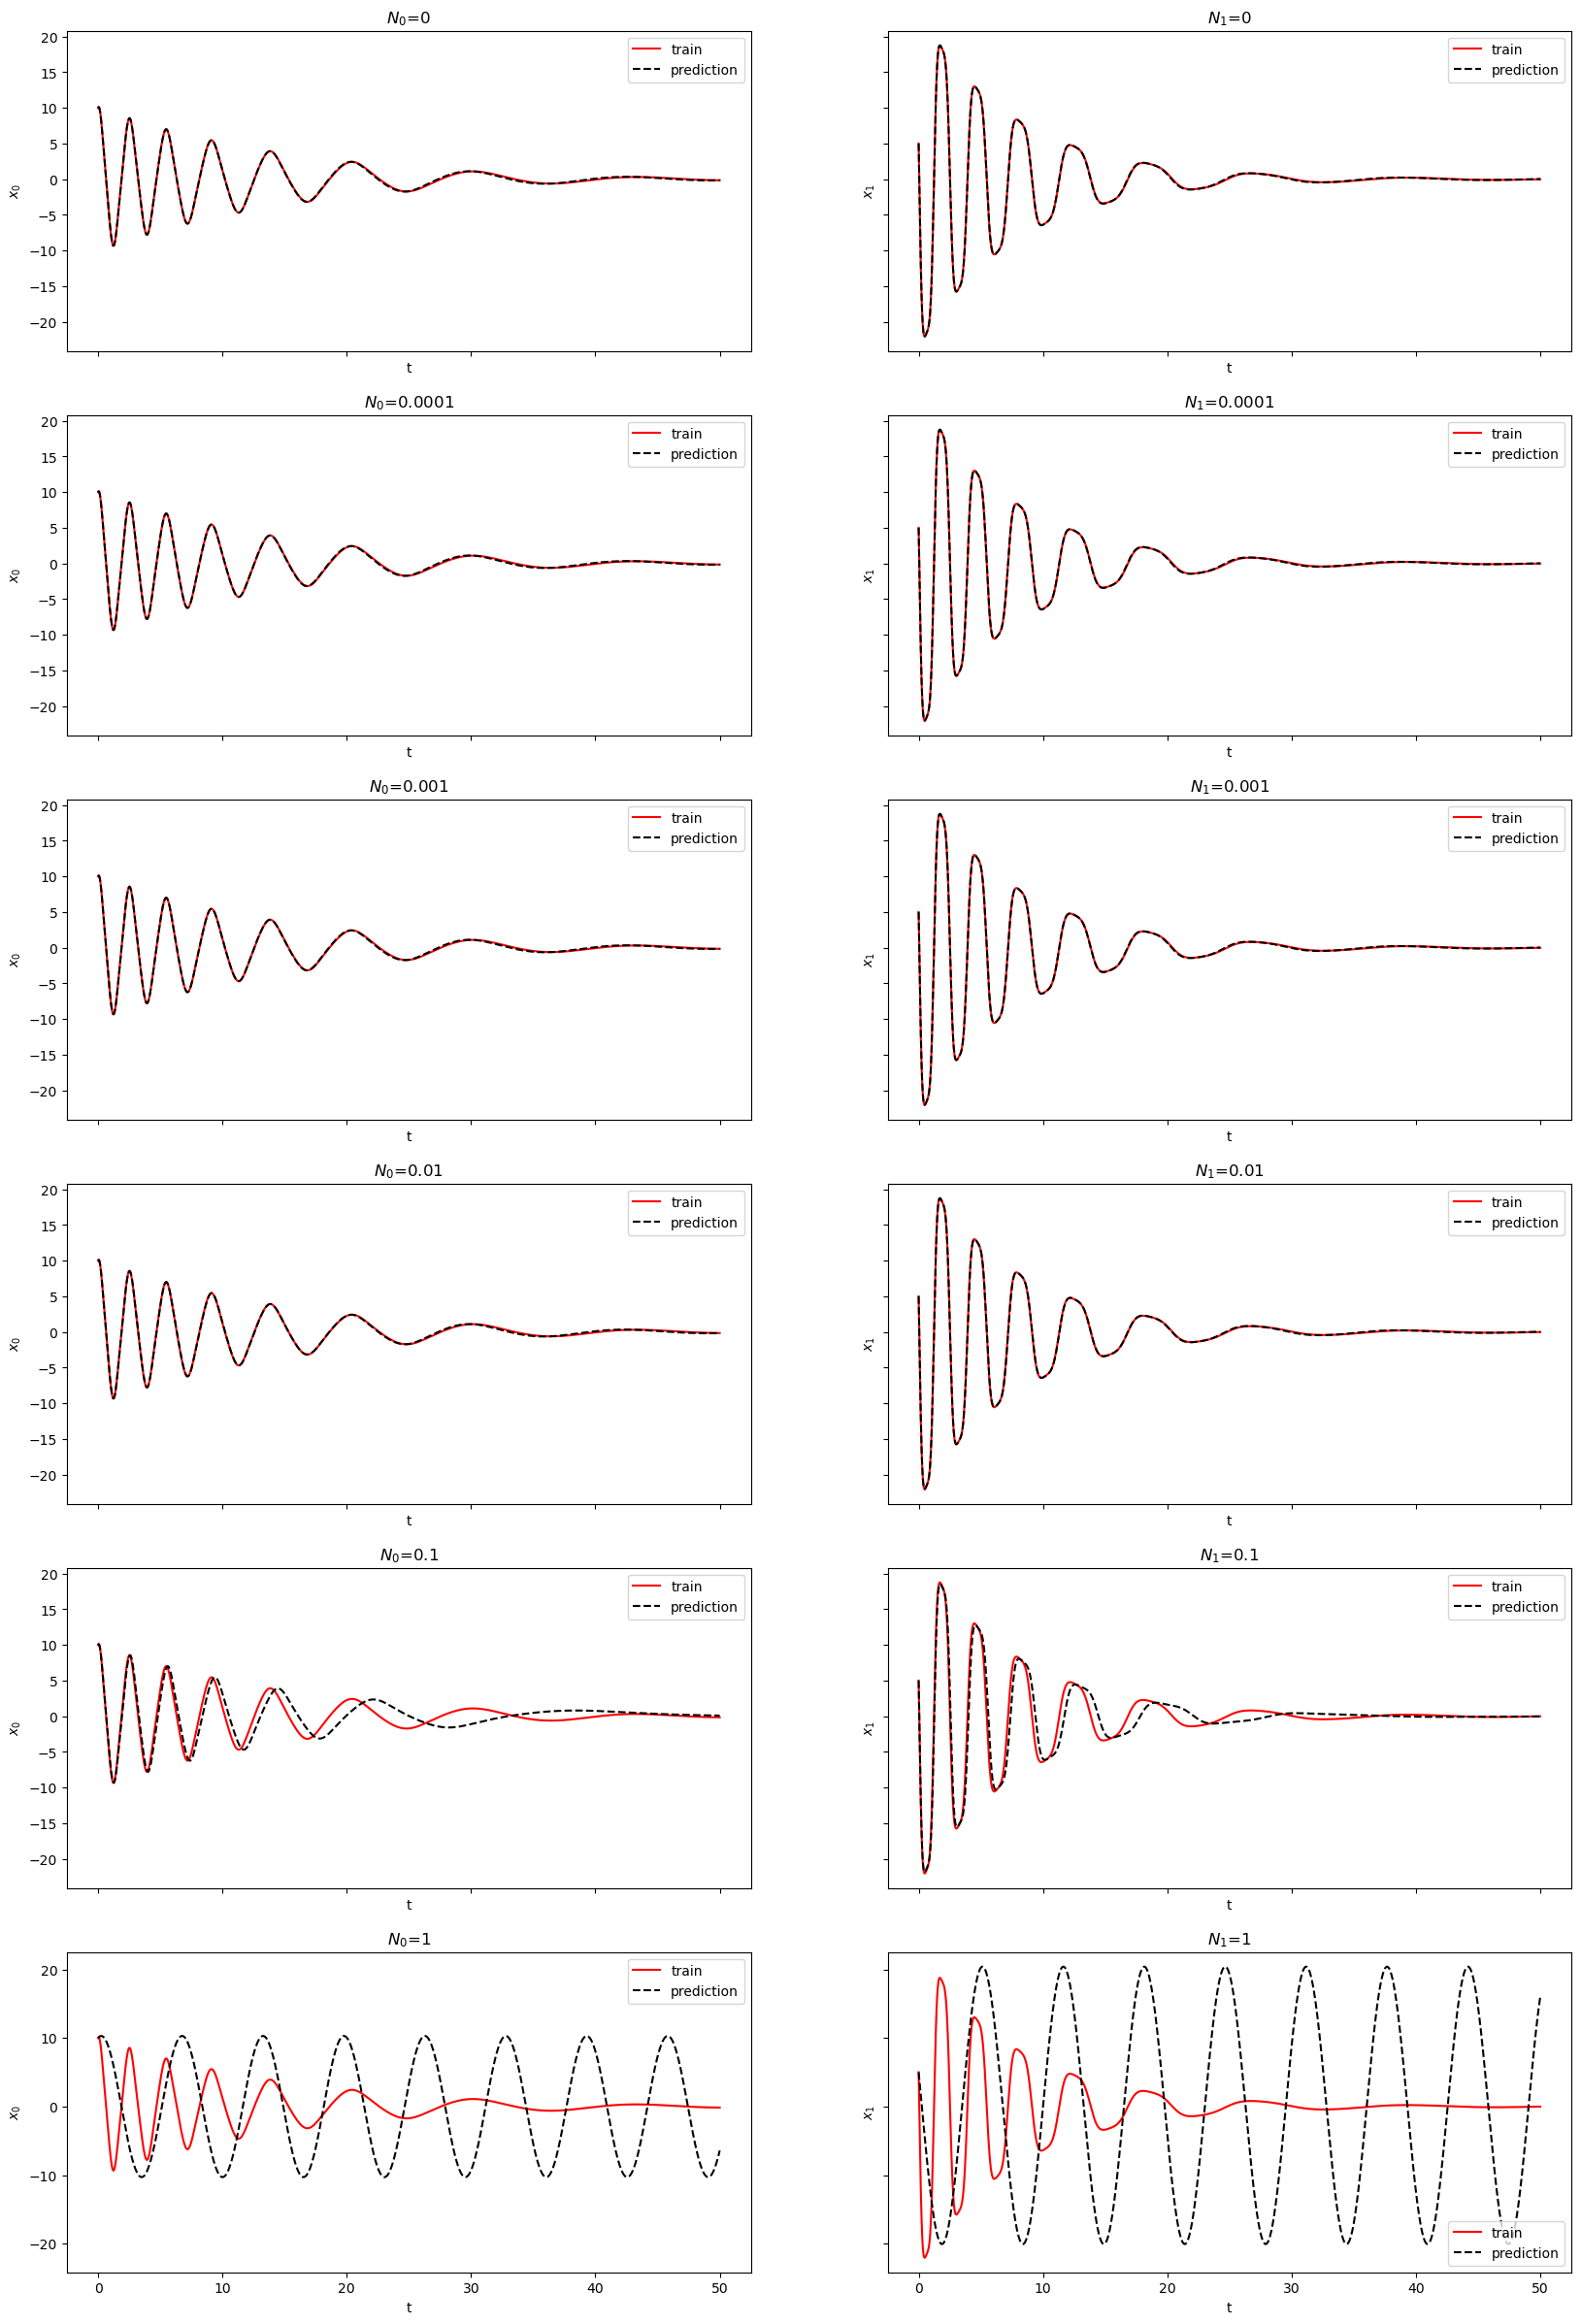

In [54]:
n_noise_levels = len(noise_levels)
n_svs = len(x0)

fig, axs = plt.subplots(n_noise_levels, n_svs, figsize=(10*n_svs, 5*n_noise_levels), sharex='col', sharey='row')

for noise_level_idx in range(n_noise_levels):
    for sv_idx in range(n_svs):
        # plot the sv_idx'th training state variable
        axs[noise_level_idx, sv_idx].plot(t_eval, x_train[sv_idx], "r", label="train")
        
        # plot the sv_idx'th state variable model prediction
        axs[noise_level_idx, sv_idx].plot(t_eval, x_preds[noise_level_idx][sv_idx], "k--", label="prediction")

        # set the title and labels
        axs[noise_level_idx, sv_idx].set_title(f"$N_{sv_idx}$={noise_levels[noise_level_idx]}")
        axs[noise_level_idx, sv_idx].set_xlabel("t")
        axs[noise_level_idx, sv_idx].set_ylabel(f"$x_{sv_idx}$")
        axs[noise_level_idx, sv_idx].legend()

fig.show()

In [55]:
for i in range(len(noise_levels)):
    rte = relative_frobenius_error(x_train, x_preds[i])
    print(f"noise level: {noise_levels[i]:.6f}, relative trajectory error: {rte:.6f}")

noise level: 0.000000, relative trajectory error: 0.017594
noise level: 0.000100, relative trajectory error: 0.017588
noise level: 0.001000, relative trajectory error: 0.017609
noise level: 0.010000, relative trajectory error: 0.021569
noise level: 0.100000, relative trajectory error: 0.331978
noise level: 1.000000, relative trajectory error: 2.876577
